# ☀️ Syria SolarScope
**FTL Syria AI4Climate – Python for Climate Hackathon (28 Sep – 2 Oct 2026)**

**Team Number:** `8`  |  **Team members:** Jawad Osama Alshepli Azzam, Hadi Alkhaier, Ibrahim Solaiman, Mahmoud Mamo, Mohamad Fattouh, Mohammad Zain Kabbany

| | |
|---|---|
| **Climate challenge** | Renewable energy and energy efficiency |
| **Climate problem** | Severe electricity shortages in Syria push households and businesses toward solar energy, but owners lack location-specific production estimates, leading to poorly sized and costly installations. Output varies by governorate and season, heat reduces panel efficiency, and buyers are unsure about the long-term cost per kWh. |
| **Main research question** | How do solar irradiance and temperature-adjusted photovoltaic output vary across Syria's 14 governorates and months during 2015–2025, and what are the expected monthly energy yield ranges and levelized energy costs (cost per kWh) for standard system capacities given varying upfront installation costs? |
| **Dataset** | NASA POWER daily data (2015–2025): `ALLSKY_SFC_SW_DWN` (solar radiation), `T2M` (mean temperature), `T2M_MAX` (max temperature, added to estimate panel temperature) — https://power.larc.nasa.gov/data-access-viewer/ |
| **Solution type** | Decision-support tool (web-based Streamlit app: `app.py`) powered by the analysis in this notebook |

**Pipeline:** Climate problem → Data → Python analysis → Visualisation → Findings → Proposed solution

## 1. Setup

In [1]:
import os, time
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})
try:
    display
except NameError:
    display = print

## 2. The model (physics + economics)
Same code as `core.py` in the app, so the notebook and the app always agree.

* **Physics:** daily radiation → cell temperature → temperature loss → daily yield per kWp.
* **Economics:** LCOE = (capex + discounted O&M) / discounted lifetime energy, 20 years, 8 % discount rate, 0.7 %/yr degradation.

In [2]:
import numpy as np

# fixed inputs of the model
LIFETIME_YEARS = 20       # system life
DEGRADATION = 0.007       # panels lose 0.7% output each year
GAMMA = -0.0035           # power loss per degC above 25
OM_SHARE = 0.10           # yearly O&M as share of cost, with batteries
OM_NO_BATTERY = 0.02      # same but without batteries
DISCOUNT_RATE = 0.08
NOCT = 45.0               # panel operating temp, degC
DAYLIGHT_H = 12.0         # hours used to turn daily ghi into watts/m2
OTHER_LOSSES = 0.14       # inverter, wires, dust
PANEL_W = 550             # watt per panel

# grid price used for comparison (tier 2, SYP per kWh)
SYP_PER_USD = 13_500   # SYP per USD used for the grid comparison
GRID_TIER2_SYP = 1_400
GRID_TIER2_USD = GRID_TIER2_SYP / SYP_PER_USD

# df needs columns ghi (kWh/m2/day), t_mean, t_max (degC)
def add_physics(df):
    d = df.copy()
    d["t_day"] = (d.t_mean + d.t_max) / 2
    g = d.ghi * 1000 / DAYLIGHT_H
    d["t_cell"] = d.t_day + (NOCT - 20) / 800 * g
    d["f_temp"] = (1 + GAMMA * (d.t_cell - 25)).clip(upper=1.0)
    d["y_ideal"] = d.ghi * (1 - OTHER_LOSSES)
    d["y_real"] = d.y_ideal * d.f_temp
    return d

def _q(p):
    return lambda s: s.quantile(p)

def monthly_stats(d):
    m = d.groupby(["governorate", "year", "month"])[["y_ideal", "y_real"]].sum().reset_index()
    s = (m.groupby(["governorate", "month"])["y_real"]
           .agg(mean="mean", low=_q(.10), high=_q(.90)).reset_index())
    t = m.groupby(["governorate", "month"])[["y_ideal", "y_real"]].sum()
    s["heat_loss"] = (1 - t.y_real / t.y_ideal).values
    return s, m

def annual_stats(m):
    a = m.groupby(["governorate", "year"])[["y_ideal", "y_real"]].sum().reset_index()
    s = (a.groupby("governorate")["y_real"]
           .agg(mean="mean", low=_q(.10), high=_q(.90)))
    t = a.groupby("governorate")[["y_ideal", "y_real"]].sum()
    s["heat_loss"] = 1 - t.y_real / t.y_ideal
    s["cv"] = a.groupby("governorate")["y_real"].std() / s["mean"]
    return s.reset_index()

# capex in USD, e1_kwh = energy of the first year in kWh
def lcoe(capex, e1_kwh, rate=DISCOUNT_RATE, years=LIFETIME_YEARS,
         degr=DEGRADATION, om_share=OM_NO_BATTERY):
    if capex <= 0 or e1_kwh <= 0:
        return float("nan")
    t = np.arange(1, years + 1)
    disc = (1 + rate) ** t
    energy = e1_kwh * (1 - degr) ** (t - 1)
    return (capex + (om_share * capex / disc).sum()) / (energy / disc).sum()

def kw_from_panels(n, watt=PANEL_W):
    return n * watt / 1000

## 3. Data: download, inspect, clean

In [3]:
GOVS = {
    "Damascus": (33.51, 36.29), "Rif Dimashq": (33.57, 36.40), "Aleppo": (36.20, 37.16),
    "Homs": (34.73, 36.72), "Hama": (35.13, 36.75), "Latakia": (35.52, 35.79),
    "Tartus": (34.89, 35.89), "Idlib": (35.93, 36.63), "Deir ez-Zor": (35.34, 40.14),
    "Raqqa": (35.95, 39.01), "Hasakah": (36.50, 40.75), "Daraa": (32.62, 36.10),
    "As-Suwayda": (32.71, 36.57), "Quneitra": (33.13, 35.82),
}
START, END = 2015, 2025
URL = "https://power.larc.nasa.gov/api/temporal/daily/point"
RAW_CSV = "power_syria_daily_2015_2025.csv"

def fetch(lat, lon, tries=3):
    p = dict(parameters="ALLSKY_SFC_SW_DWN,T2M,T2M_MAX", community="RE", latitude=lat,
             longitude=lon, start=f"{START}0101", end=f"{END}1231", format="JSON")
    for i in range(tries):
        try:
            r = requests.get(URL, params=p, timeout=120)
            r.raise_for_status()
            df = pd.DataFrame(r.json()["properties"]["parameter"])
            df.index = pd.to_datetime(df.index, format="%Y%m%d")
            return df.replace(-999, np.nan)
        except requests.RequestException:
            time.sleep(3 * (i + 1))
    raise RuntimeError(f"NASA POWER download failed for {lat},{lon}")

if os.path.exists(RAW_CSV):
    raw = pd.read_csv(RAW_CSV, parse_dates=["date"])
    print("Loaded cached", RAW_CSV)
else:
    frames = []
    for gov, (lat, lon) in GOVS.items():
        d = fetch(lat, lon); d["governorate"] = gov; frames.append(d)
        print("downloaded", gov)
    raw = (pd.concat(frames).rename_axis("date").reset_index()
             .rename(columns={"ALLSKY_SFC_SW_DWN": "ghi", "T2M": "t_mean", "T2M_MAX": "t_max"}))
    raw.to_csv(RAW_CSV, index=False)
raw.head()

Loaded cached power_syria_daily_2015_2025.csv


,date,ghi,t_mean,t_max,governorate
0,2015-01-01,3.1318,8.21,15.36,Damascus
1,2015-01-02,2.2690,6.13,9.99,Damascus
2,2015-01-03,2.3784,5.48,9.61,Damascus
3,2015-01-04,2.6148,5.84,9.58,Damascus
4,2015-01-05,2.0496,6.23,9.75,Damascus


In [4]:
print("shape:", raw.shape, "| governorates:", raw.governorate.nunique(), "| period:", raw.date.min().date(), "->", raw.date.max().date())
print("\nmissing values per column:\n", raw[["ghi", "t_mean", "t_max"]].isna().sum())
display(raw[["ghi", "t_mean", "t_max"]].describe().round(2))

shape: (56252, 5) | governorates: 14 | period: 2015-01-01 -> 2025-12-31

missing values per column:
 ghi       0
t_mean    0
t_max     0
dtype: int64


,ghi,t_mean,t_max
count,56252.00,56252.00,56252.00
mean,5.32,18.83,25.63
std,2.18,8.40,9.43
min,0.34,-6.03,-0.45
25%,3.40,11.56,17.62
50%,5.47,19.47,25.82
75%,7.33,26.01,33.81
max,9.03,38.92,49.58


**Variables**

| Variable | Meaning | Unit |
|---|---|---|
| `ghi` | Global horizontal irradiance (daily solar energy on a flat surface) | kWh/m²/day |
| `t_mean` | Mean daily air temperature at 2 m | °C |
| `t_max` | Maximum daily air temperature at 2 m | °C |
| `governorate` | One of 14 Syrian governorates (centre point) | – |

In [5]:
cols = ["ghi", "t_mean", "t_max"]
before = len(raw)
raw[cols] = raw.groupby("governorate")[cols].transform(lambda s: s.interpolate(limit=3))
clean = raw.dropna(subset=cols).copy()
assert clean.ghi.between(0, 12).all(), "GHI out of physical range"
print(f"rows: {before} -> {len(clean)} (dropped {before-len(clean)} after interpolation)")

rows: 56252 -> 56252 (dropped 0 after interpolation)


## 4. Python analysis

In [6]:
d = add_physics(clean)
d["year"], d["month"] = d.date.dt.year, d.date.dt.month
ms, m = monthly_stats(d)
a = annual_stats(m)
a = a.sort_values("mean", ascending=False).reset_index(drop=True)
display(a.round(3))

,governorate,mean,low,high,heat_loss,cv
0,As-Suwayda,1671.366,1646.619,1708.911,0.058,0.016
1,Daraa,1668.659,1643.143,1706.683,0.060,0.016
2,Damascus,1651.521,1630.038,1679.508,0.055,0.015
3,Rif Dimashq,1651.521,1630.038,1679.508,0.055,0.015
4,Quneitra,1574.458,1541.604,1615.252,0.062,0.018
5,Homs,1566.258,1546.392,1594.293,0.058,0.017
6,Tartus,1562.722,1541.948,1587.078,0.051,0.015
7,Raqqa,1557.698,1530.365,1592.829,0.063,0.017
8,Latakia,1536.139,1512.414,1561.324,0.050,0.014
9,Deir ez-Zor,1533.717,1496.776,1563.080,0.065,0.022


### Analysis 1 — Ranking: which governorates produce the most?

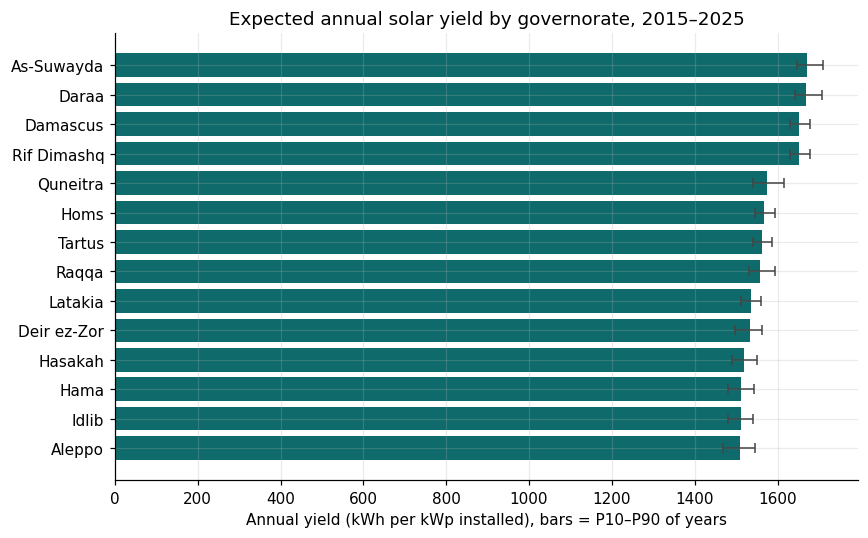

Best: As-Suwayda (1,671 kWh/kWp) | lowest: Aleppo (1,510) | spread 10.7%


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(a.governorate[::-1], a["mean"][::-1], color="#0f6b6b")
ax.errorbar(a["mean"][::-1], range(len(a)), xerr=[(a["mean"]-a.low)[::-1], (a.high-a["mean"])[::-1]],
            fmt="none", ecolor="#444", capsize=3, lw=1)
ax.set_xlabel("Annual yield (kWh per kWp installed), bars = P10–P90 of years")
ax.set_title("Expected annual solar yield by governorate, 2015–2025")
plt.tight_layout(); plt.savefig("figures/01_yield_ranking.png"); plt.show()
spread = (a["mean"].max() / a["mean"].min() - 1) * 100
print(f"Best: {a.governorate.iloc[0]} ({a['mean'].iloc[0]:,.0f} kWh/kWp) | lowest: {a.governorate.iloc[-1]} ({a['mean'].iloc[-1]:,.0f}) | spread {spread:.1f}%")

### Analysis 2 — Seasonality and heat loss (changes over time, grouping)

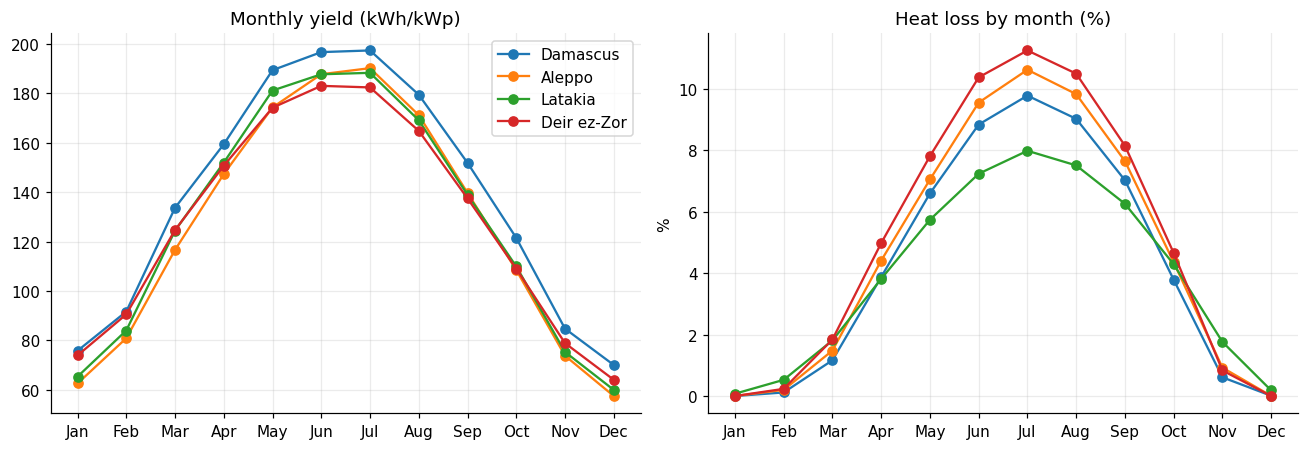

Heat loss is highest in Jul (10.0%) and lowest in Jan (0.0%).


In [8]:
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
show = [g for g in ["Damascus", "Aleppo", "Latakia", "Deir ez-Zor"] if g in set(ms.governorate)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
for g in show:
    s = ms[ms.governorate == g].sort_values("month")
    ax1.plot(MONTHS, s["mean"], marker="o", label=g)
    ax2.plot(MONTHS, s.heat_loss * 100, marker="o", label=g)
ax1.set_title("Monthly yield (kWh/kWp)"); ax1.legend()
ax2.set_title("Heat loss by month (%)"); ax2.set_ylabel("%")
plt.tight_layout(); plt.savefig("figures/02_seasonality_heat_loss.png"); plt.show()
peak = ms.groupby("month")["heat_loss"].mean()
print(f"Heat loss is highest in {MONTHS[peak.idxmax()-1]} ({peak.max()*100:.1f}%) and lowest in {MONTHS[peak.idxmin()-1]} ({peak.min()*100:.1f}%).")

### Analysis 3 — Reliability: year-to-year variability and trend (percent change between periods)

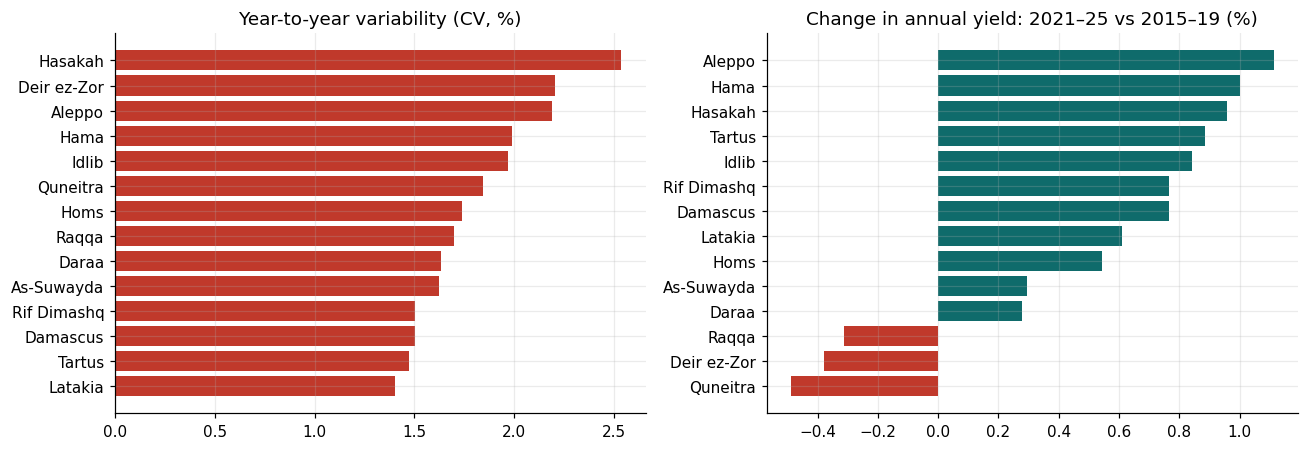

CV ranges 1.4%–2.5%; national average change between periods: +0.49%


In [9]:
yr = d.groupby(["governorate", "year"])["y_real"].sum().reset_index()
early = yr[yr.year <= 2019].groupby("governorate")["y_real"].mean()
late = yr[yr.year >= 2021].groupby("governorate")["y_real"].mean()
change = ((late / early - 1) * 100).sort_values()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
cv = a.set_index("governorate")["cv"].sort_values() * 100
ax1.barh(cv.index, cv.values, color="#c0392b"); ax1.set_title("Year-to-year variability (CV, %)")
ax2.barh(change.index, change.values, color=np.where(change.values >= 0, "#0f6b6b", "#c0392b"))
ax2.set_title("Change in annual yield: 2021–25 vs 2015–19 (%)")
plt.tight_layout(); plt.savefig("figures/03_variability_trend.png"); plt.show()
print(f"CV ranges {cv.min():.1f}%–{cv.max():.1f}%; national average change between periods: {change.mean():+.2f}%")

### Analysis 4 — Threshold detection and correlation: how often does heat cut output noticeably?

Average days per year with >10% temperature loss:


governorate,Hasakah,Deir ez-Zor,Raqqa,Aleppo,Idlib,Hama,Quneitra,As-Suwayda,Daraa,Homs,Damascus,Rif Dimashq,Latakia,Tartus
days/yr,83,76,67,49,46,34,28,28,26,24,20,20,0,0


,ghi,t_day,t_cell,heat_loss_day
ghi,1.00,0.75,0.90,0.88
t_day,0.75,1.00,0.96,0.94
t_cell,0.90,0.96,1.00,0.98
heat_loss_day,0.88,0.94,0.98,1.00


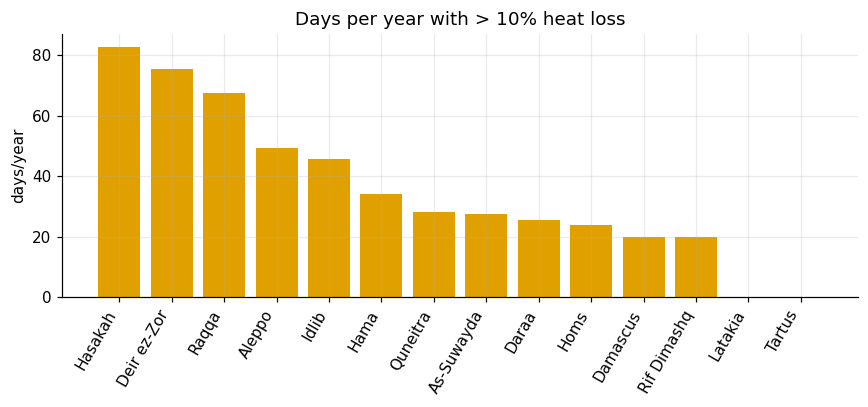

In [10]:
d["heat_loss_day"] = 1 - d.f_temp
hot = d.assign(hot=d.heat_loss_day > 0.10).groupby(["governorate", "year"])["hot"].sum().groupby("governorate").mean().sort_values(ascending=False)
print("Average days per year with >10% temperature loss:")
display(hot.round(0).astype(int).to_frame("days/yr").T)
corr = d[["ghi", "t_day", "t_cell", "heat_loss_day"]].corr().round(2)
display(corr)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(hot.index, hot.values, color="#e0a000"); ax.set_ylabel("days/year"); ax.set_title("Days per year with > 10% heat loss")
plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.savefig("figures/04_hot_days.png"); plt.show()

## 5. From energy to money — LCOE vs the Syrian grid tariff

Example: 10 panels = 5.5 kW in Damascus: 9,083 kWh/yr (P10–P90: 8,965–9,237)
LCOE without batteries (O&M 2%): $0.070/kWh | with batteries (O&M 10%): $0.117/kWh | grid tier 2: $0.104/kWh
Solar without batteries is 32% cheaper than grid tier 2.


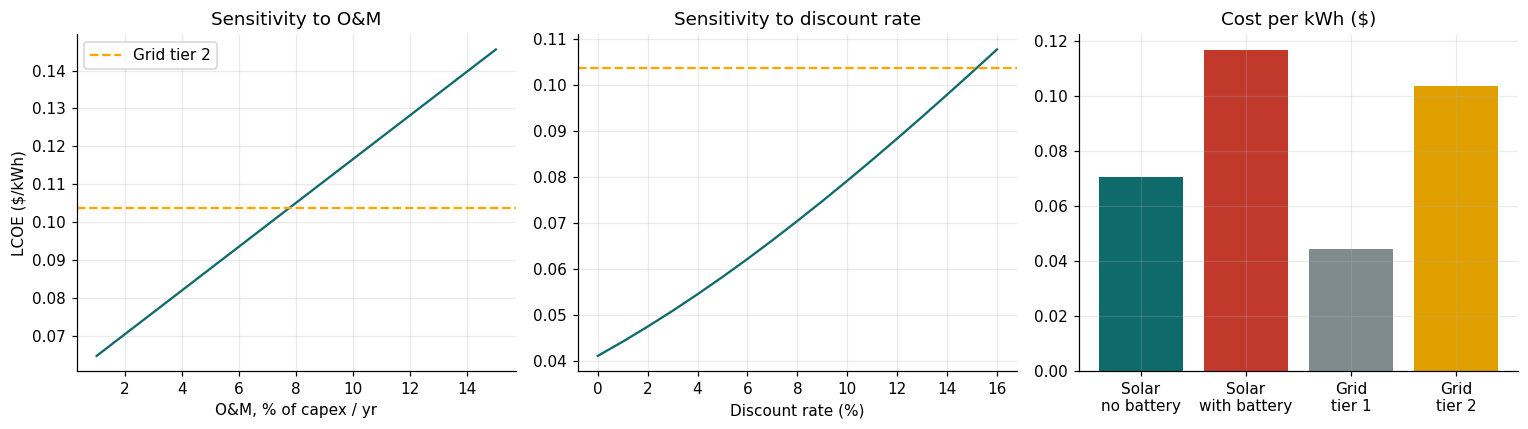

In [11]:
GRID = GRID_TIER2_USD
dam = a[a.governorate == "Damascus"].iloc[0] if "Damascus" in set(a.governorate) else a.iloc[0]
kw = kw_from_panels(10)
e1 = dam["mean"] * kw
no_b = lcoe(5000, e1); with_b = lcoe(5000, e1, om_share=OM_SHARE)
print(f"Example: 10 panels = {kw} kW in {dam.governorate}: {e1:,.0f} kWh/yr (P10–P90: {dam.low*kw:,.0f}–{dam.high*kw:,.0f})")
print(f"LCOE without batteries (O&M 2%): ${no_b:.3f}/kWh | with batteries (O&M 10%): ${with_b:.3f}/kWh | grid tier 2: ${GRID:.3f}/kWh")
print(f"Solar without batteries is {(1-no_b/GRID)*100:.0f}% cheaper than grid tier 2.")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
om = np.linspace(0.01, 0.15, 30)
ax1.plot(om * 100, [lcoe(5000, e1, om_share=x) for x in om], color="#0f6b6b")
ax1.axhline(GRID, color="orange", ls="--", label="Grid tier 2"); ax1.set_xlabel("O&M, % of capex / yr"); ax1.set_ylabel("LCOE ($/kWh)"); ax1.set_title("Sensitivity to O&M"); ax1.legend()
rates = np.linspace(0, 0.16, 17)
ax2.plot(rates * 100, [lcoe(5000, e1, rate=r) for r in rates], color="#0f6b6b")
ax2.axhline(GRID, color="orange", ls="--"); ax2.set_xlabel("Discount rate (%)"); ax2.set_title("Sensitivity to discount rate")
ax3.bar(["Solar\nno battery", "Solar\nwith battery", "Grid\ntier 1", "Grid\ntier 2"], [no_b, with_b, 600 / SYP_PER_USD, GRID],
        color=["#0f6b6b", "#c0392b", "#7f8c8d", "#e0a000"])
ax3.set_title("Cost per kWh ($)")
plt.tight_layout(); plt.savefig("figures/05_lcoe_vs_grid.png"); plt.show()

### Sanity check of the LCOE function and the break-even cost


In [12]:
# Known-answer test: with no discounting, no degradation and no O&M, LCOE = capex / (yearly energy x years)
assert abs(lcoe(5000, 9000, rate=0, degr=0, om_share=0) - 5000 / (9000 * LIFETIME_YEARS)) < 1e-12
print('LCOE known-answer test passed')

# Break-even: highest upfront cost at which the battery system still matches grid tier 2 (simple bisection)
lo, hi = 1000.0, 20000.0
for _ in range(60):
    mid = (lo + hi) / 2
    if lcoe(mid, e1, om_share=OM_SHARE) > GRID: hi = mid
    else: lo = mid
print(f'With batteries, solar stays below grid tier 2 up to a capital cost of about ${lo:,.0f} for this {kw} kW system')


LCOE known-answer test passed
With batteries, solar stays below grid tier 2 up to a capital cost of about $4,445 for this 5.5 kW system


## 6. Save tables for the app and print the key findings

In [13]:
ms.to_csv("monthly_stats.csv", index=False)
a.sort_values("governorate").to_csv("annual_stats.csv", index=False)
print("Saved monthly_stats.csv, annual_stats.csv  (the Streamlit app reads these two files)\n")
print("KEY FINDINGS")
print(f"1. Best governorate: {a.governorate.iloc[0]} ({a['mean'].iloc[0]:,.0f} kWh/kWp/yr); lowest: {a.governorate.iloc[-1]} ({a['mean'].iloc[-1]:,.0f}). Spread {spread:.1f}%.")
print(f"2. Heat reduces output by {a.heat_loss.min()*100:.1f}%–{a.heat_loss.max()*100:.1f}% a year; worst month {MONTHS[peak.idxmax()-1]} ({peak.max()*100:.1f}%).")
print(f"3. Year-to-year variability (CV) is {cv.min():.1f}%–{cv.max():.1f}% (low CV = predictable yearly output).")
print(f"4. 10-panel / $5,000 system in {dam.governorate}: ${no_b:.3f}/kWh without batteries vs grid tier 2 ${GRID:.3f}/kWh ({(1-no_b/GRID)*100:.0f}% cheaper); with batteries ${with_b:.3f}/kWh.")

Saved monthly_stats.csv, annual_stats.csv  (the Streamlit app reads these two files)

KEY FINDINGS
1. Best governorate: As-Suwayda (1,671 kWh/kWp/yr); lowest: Aleppo (1,510). Spread 10.7%.
2. Heat reduces output by 5.0%–6.7% a year; worst month Jul (10.0%).
3. Year-to-year variability (CV) is 1.4%–2.5% (low CV = predictable yearly output).
4. 10-panel / $5,000 system in Damascus: $0.070/kWh without batteries vs grid tier 2 $0.104/kWh (32% cheaper); with batteries $0.117/kWh.


## 7. Proposed solution & impact
**Syria SolarScope** (Streamlit app, `app.py`): the user picks a governorate, enters system size (kW or number of panels) and cost, and gets expected yearly output with a realistic low–high range, heat-loss percentage, the LCOE, and a comparison with the official Syrian grid tariffs. It helps households and small businesses decide on solar using location-based numbers to check a seller's offer.

Run locally: `pip install -r requirements.txt` → `streamlit run app.py` (needs `monthly_stats.csv` and `annual_stats.csv` produced above).

## 8. Limitations & next steps
1. NASA POWER grid cells are ~0.5° — neighbouring governorates can fall in the same cell. In our download Damascus/Rif Dimashq, Daraa/As-Suwayda and Hama/Idlib share the same irradiance series, so the 14 governorates are backed by 11 distinct irradiance cells (Damascus and Rif Dimashq have identical results).
2. Radiation is on a horizontal surface; tilted panels would produce somewhat more (our estimate is conservative).
3. Cell temperature is approximated from daily data (NOCT model), not measured.
4. The 14 % non-thermal losses assume regular panel cleaning (dust).
5. LCOE is dominated by financial assumptions (O&M share, discount rate) — verify against the real seller's contract.
6. Prices are in USD; exchange-rate changes and tariff decrees change the economics.
7. Results are for planning only — not a price quote or guarantee. External validation (PVGIS / Global Solar Atlas) is still recommended.

**Next steps:** compare LCOE with diesel-generator electricity; add panel tilt; connect to up-to-date Syrian market prices; compare several governorates side by side; auto-update tariffs.

**Data & references:** NASA POWER (https://power.larc.nasa.gov/); tariffs: Syrian Ministry of Energy tiered pricing effective 1 Nov 2025 (The National, 5 Nov 2025; Enab Baladi, 31 Oct 2025); NREL PV cost benchmarks (O&M).